In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay
import joblib
import json
import os
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/creditcard.csv")
print("Dimensions :", df.shape)
df.head()

Dimensions : (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

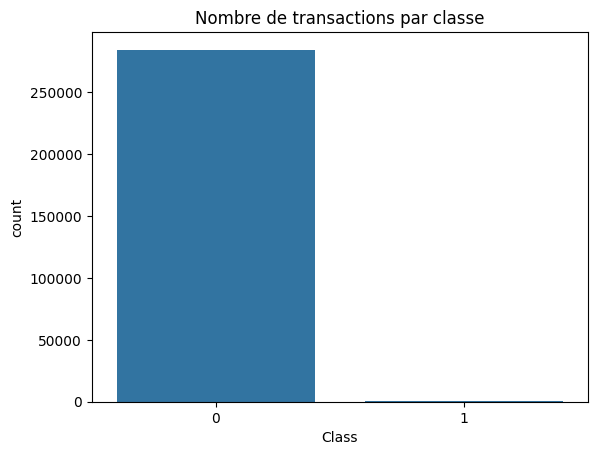

In [ ]:
sns.countplot(x="Class", data=df)
plt.title("Nombre de transactions par classe")
plt.show()

In [8]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

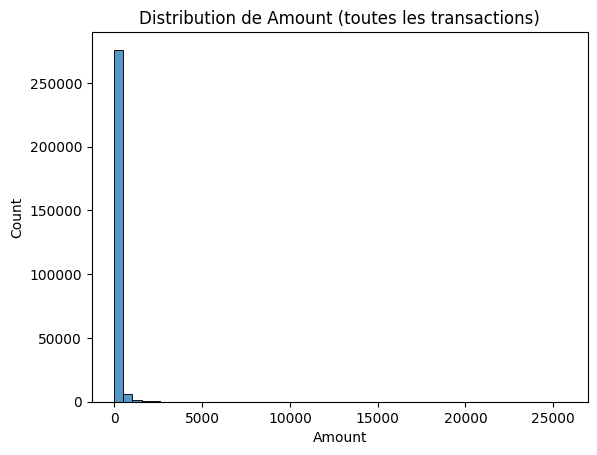

In [9]:
sns.histplot(df["Amount"], bins=50)
plt.title("Distribution de Amount (toutes les transactions)")
plt.show()

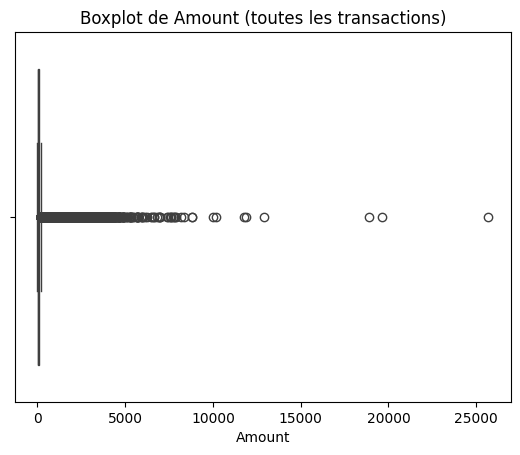

In [10]:
sns.boxplot(x=df["Amount"])
plt.title("Boxplot de Amount (toutes les transactions)")
plt.show()

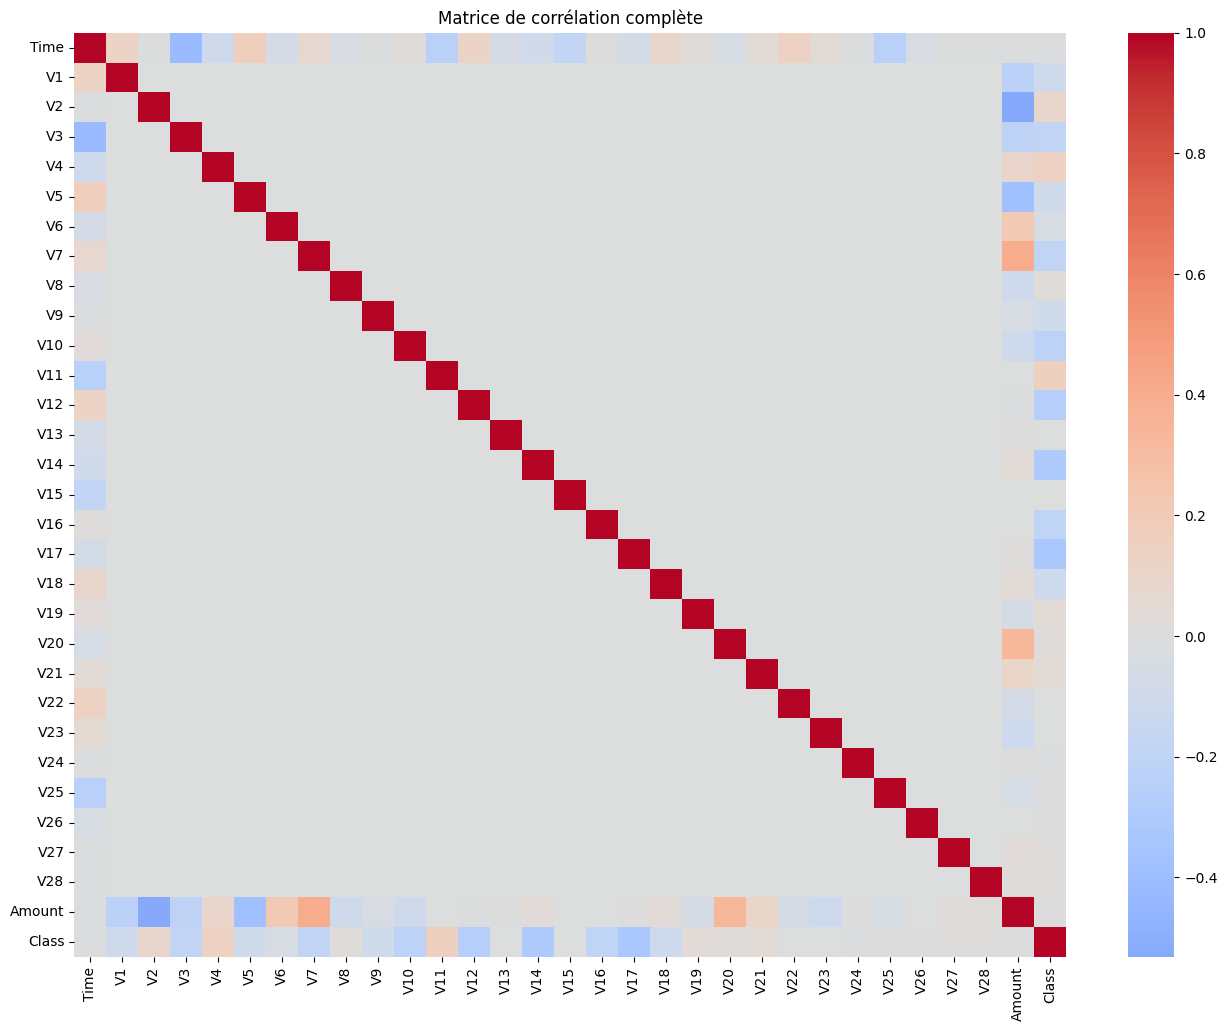

In [13]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Matrice de corrélation complète")
plt.show()

In [14]:
df[["Time", "Amount"]].skew()

Time      -0.035568
Amount    16.977724
dtype: float64

In [15]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("X :", X.shape)
print("y :", y.shape)

X : (284807, 30)
y : (284807,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Taux de fraude - train :", y_train.mean())
print("Taux de fraude - test  :", y_test.mean())

Taux de fraude - train : 0.001729245759178389
Taux de fraude - test  : 0.0017204452090867595


In [ ]:
scaler_amount = StandardScaler()
scaler_time = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["Amount"] = scaler_amount.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler_amount.transform(X_test[["Amount"]])

X_train["Time"] = scaler_time.fit_transform(X_train[["Time"]])
X_test["Time"] = scaler_time.transform(X_test[["Time"]])

X_train[["Amount", "Time"]].describe()

,Amount,Time
count,2.278450e+05,2.278450e+05
mean,-2.020811e-17,-1.407707e-16
std,1.000002e+00,1.000002e+00
min,-3.516894e-01,-1.998073e+00
25%,-3.291944e-01,-8.561495e-01
50%,-2.639429e-01,-2.122647e-01
75%,-4.262209e-02,9.366285e-01
max,1.021170e+02,1.640549e+00


In [ ]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

print("Entraînement terminé.")

Entraînement terminé.


In [ ]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=3, target_names=["Normale", "Fraude"]))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC  :", round(average_precision_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

     Normale      1.000     0.976     0.988     56864
      Fraude      0.061     0.918     0.114        98

    accuracy                          0.976     56962
   macro avg      0.530     0.947     0.551     56962
weighted avg      0.998     0.976     0.986     56962

ROC-AUC : 0.9722
PR-AUC  : 0.7159


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", max_depth=12,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

print("Entraînement terminé.")

Entraînement terminé.


In [21]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, digits=3, target_names=["Normale", "Fraude"]))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba_rf), 4))
print("PR-AUC  :", round(average_precision_score(y_test, y_proba_rf), 4))

              precision    recall  f1-score   support

     Normale      1.000     1.000     1.000     56864
      Fraude      0.842     0.816     0.829        98

    accuracy                          0.999     56962
   macro avg      0.921     0.908     0.914     56962
weighted avg      0.999     0.999     0.999     56962

ROC-AUC : 0.9747
PR-AUC  : 0.8291


In [ ]:
# pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 12.6 MB/s eta 0:00:08
   - -------------------------------------- 3.7/101.7 MB 8.4 MB/s eta 0:00:12
   - -------------------------------------- 4.2/101.7 MB 6.0 MB/s eta 0:00:17
   -- ------------------------------------- 5.5/101.7 MB 5.9 MB/s eta 0:00:17
   -- ------------------------------------- 7.1/101.7 MB 6.1 MB/s eta 0:00:16
   --- ------------------------------------ 7.9/101.7 MB 5.9 MB/s eta 0:00:17
   --- ------------------------------------ 8.9/101.7 MB 5.7 MB/s eta 0:00:17
   ---- ----------------------------------- 10.5/101.7 MB 5.9 MB/s eta 0:00:16
   ---- ----------------------------------- 11.5/101.7 MB 5.8 MB/s eta 0:00:16
   ---- ----------------------------------- 12.6/101.7 MB 5.7 MB/s eta 0:00:16
   ----- ---------------------------------- 13.4/101.7 MB 5.6 MB/s eta 0:0


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# scale_pos_weight = ratio négatifs/positifs, l'équivalent de class_weight="balanced" pour XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=ratio, eval_metric="aucpr",
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)

print("Entraînement terminé. Ratio utilisé :", round(ratio, 1))

Entraînement terminé. Ratio utilisé : 577.3


In [25]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, digits=3, target_names=["Normale", "Fraude"]))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba_xgb), 4))
print("PR-AUC  :", round(average_precision_score(y_test, y_proba_xgb), 4))

              precision    recall  f1-score   support

     Normale      1.000     1.000     1.000     56864
      Fraude      0.882     0.837     0.859        98

    accuracy                          1.000     56962
   macro avg      0.941     0.918     0.929     56962
weighted avg      1.000     1.000     1.000     56962

ROC-AUC : 0.9684
PR-AUC  : 0.8787


In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Seuil par défaut : 0.5")
print(f"Seuil optimal (max F1) : {best_threshold:.4f}")
print(f"  -> Precision : {precisions[best_idx]:.4f}")
print(f"  -> Recall    : {recalls[best_idx]:.4f}")
print(f"  -> F1        : {f1_scores[best_idx]:.4f}")

Seuil par défaut : 0.5
Seuil optimal (max F1) : 0.9238
  -> Precision : 0.9419
  -> Recall    : 0.8265
  -> F1        : 0.8804


In [ ]:
y_pred_optimal = (y_proba_xgb >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal, digits=3, target_names=["Normale", "Fraude"]))

              precision    recall  f1-score   support

     Normale      1.000     1.000     1.000     56864
      Fraude      0.942     0.827     0.880        98

    accuracy                          1.000     56962
   macro avg      0.971     0.913     0.940     56962
weighted avg      1.000     1.000     1.000     56962



In [ ]:
os.makedirs("../models", exist_ok=True)

joblib.dump(xgb, "../models/fraud_model.joblib")
joblib.dump(scaler_amount, "../models/scaler_amount.joblib")
joblib.dump(scaler_time, "../models/scaler_time.joblib")

config = {
    "model_type": "XGBClassifier",
    "decision_threshold": float(best_threshold),
    "feature_order": list(X_train.columns),
}
with open("../models/model_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Modèle et artefacts sauvegardés dans ../models/")
print(config)

Modèle et artefacts sauvegardés dans ../models/
{'model_type': 'XGBClassifier', 'decision_threshold': 0.9237747192382812, 'feature_order': ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']}


In [ ]:
print("Fichiers dans models/ :", os.listdir("../models"))

Fichiers dans models/ : ['fraud_model.joblib', 'model_config.json', 'scaler_amount.joblib', 'scaler_time.joblib']


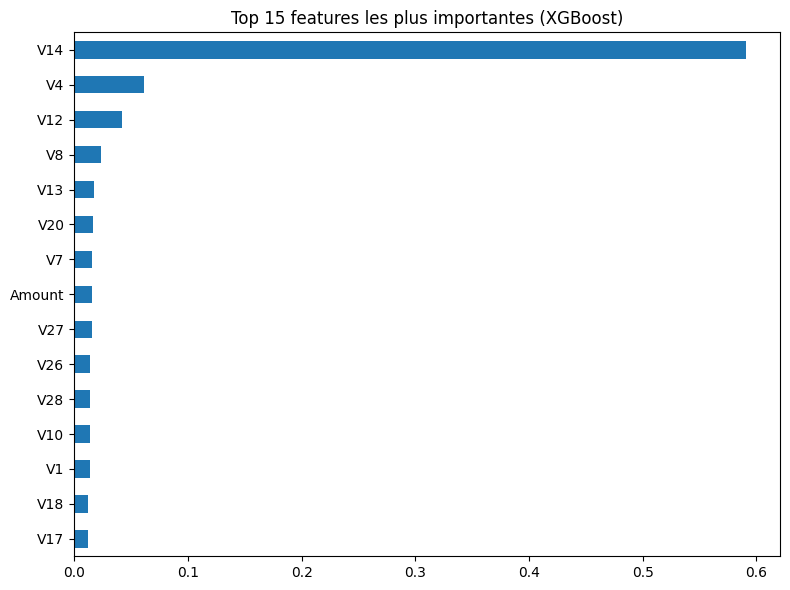

In [30]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Top 15 features les plus importantes (XGBoost)")
plt.tight_layout()
plt.show()

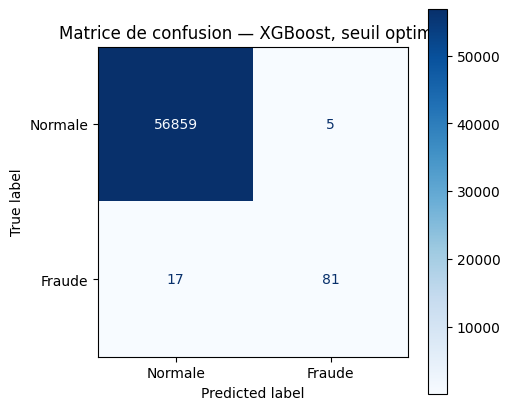

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimal, display_labels=["Normale", "Fraude"], ax=ax, cmap="Blues")
ax.set_title("Matrice de confusion — XGBoost, seuil optimal")
plt.show()

In [ ]:
# pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

xgb_smote = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric="aucpr", random_state=42, n_jobs=-1)
xgb_smote.fit(X_train_smote, y_train_smote)
y_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]

print("PR-AUC avec SMOTE    :", round(average_precision_score(y_test, y_proba_smote), 4))
print("PR-AUC sans SMOTE     :", round(average_precision_score(y_test, y_proba_xgb), 4))

PR-AUC avec SMOTE    : 0.8619
PR-AUC sans SMOTE     : 0.8787


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pr_auc_scorer = make_scorer(average_precision_score, response_method="predict_proba")

cv_scores = cross_val_score(
    XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=ratio, eval_metric="aucpr", random_state=42, n_jobs=-1),
    X_train, y_train, cv=skf, scoring=pr_auc_scorer
)

print("PR-AUC par fold :", cv_scores.round(4))
print("Moyenne :", round(cv_scores.mean(), 4), "| Écart-type :", round(cv_scores.std(), 4))

PR-AUC par fold : [0.8624 0.828  0.8428 0.8798 0.8638]
Moyenne : 0.8553 | Écart-type : 0.018
